<a href="https://colab.research.google.com/github/NyaHardy/ML_Housing-_Prediction_/blob/main/Surgical__ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports & Loading Datasets

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

In [ ]:
surgery1 = pd.read_csv("operations.csv")
diagnosis = pd.read_csv("diagnosis.csv")
ward_vitals = pd.read_csv("ward_vitals.csv")
meds = pd.read_csv("medications.csv")

/tmp/ipykernel_1123/1678408047.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  meds = pd.read_csv("medications.csv")


EDA(Exploration)

In [ ]:
target= (surgery1['inhosp_death_time'].notna() |
    surgery1['icuin_time'].notna()
).astype(int)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dist(df, col):
    sns.histplot(df[col])
    plt.title(f"{col} Distribution")
    plt.show()

def plot_box(df, col):
    sns.boxplot(x=df[col])
    plt.title(f"{col} Outliers")
    plt.show()


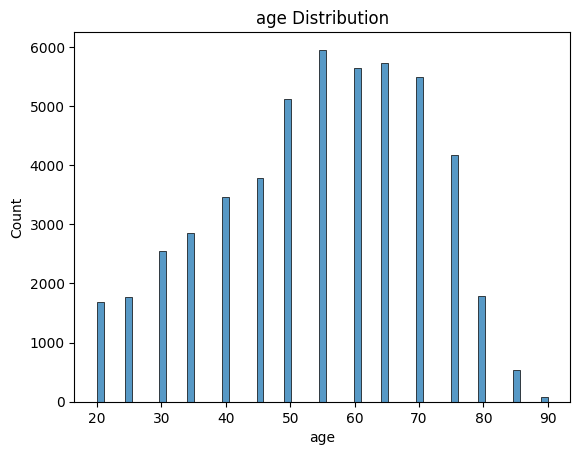

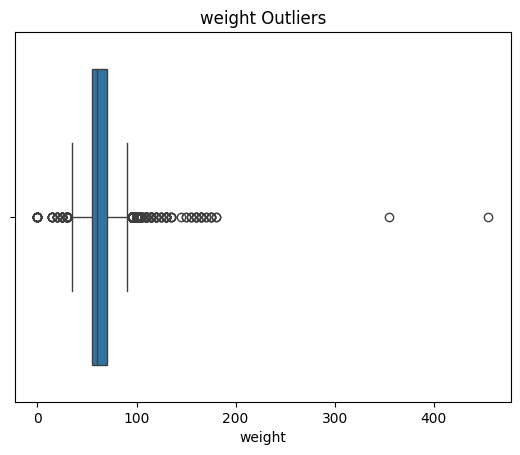

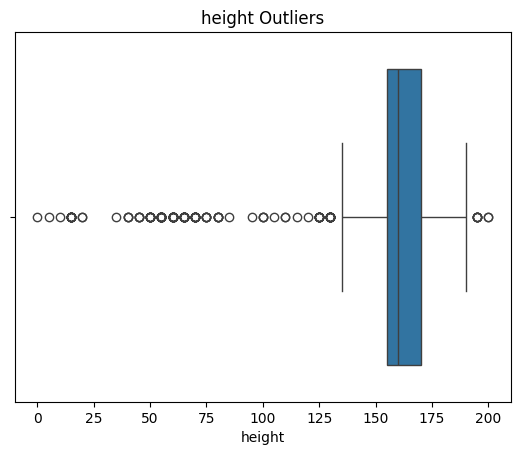

In [ ]:
plot_dist(surgery1, 'age')
plot_box(surgery1, 'weight')
plot_box(surgery1, 'height')

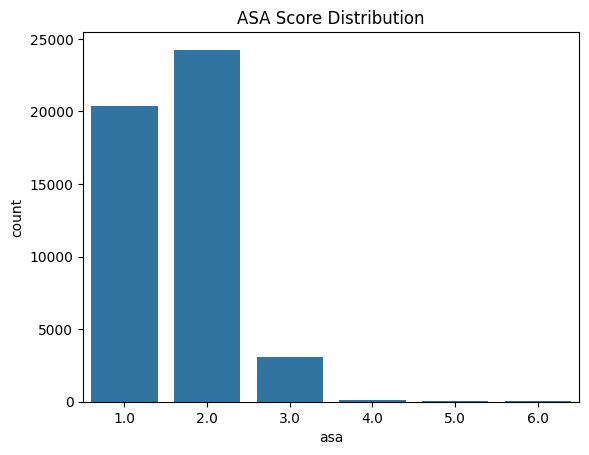

In [ ]:
sns.countplot(x='asa', data=surgery1)
plt.title("ASA Score Distribution")
plt.show()

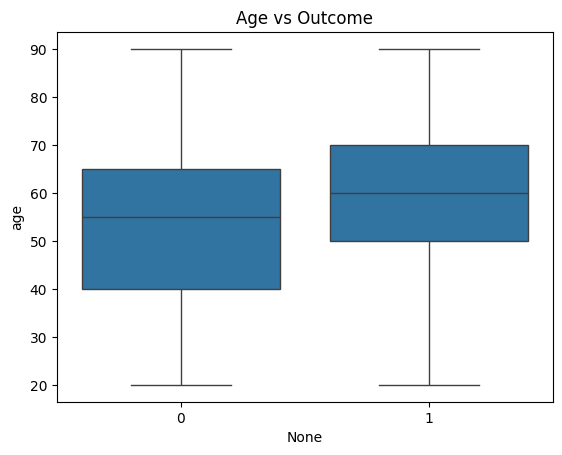

In [ ]:
sns.boxplot(x=target, y=surgery1['age'])
plt.title("Age vs Outcome")
plt.show()

Imbalanced dataset

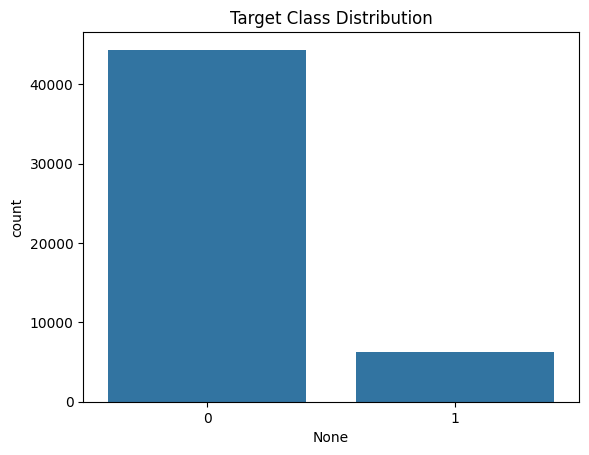

0    0.875736
1    0.124264
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x=target)
plt.title("Target Class Distribution")
plt.show()

print(target.value_counts(normalize=True))

Feature Engineering & Data Intergration

In [ ]:

surgery = surgery1[[
    'op_id','subject_id','hadm_id','age','sex','race','asa','emop',
    'antype','icd10_pcs','inhosp_death_time','icuin_time'
]].copy()

demo = surgery1[['subject_id','weight','height']].copy()

demo['height_m'] = demo['height'] / 100

demo['height_m'] = demo['height_m'].replace(0, np.nan)
demo.loc[(demo['height_m'] < 1.2) | (demo['height_m'] > 2.3), 'height_m'] = np.nan

demo['bmi'] = demo['weight'] / (demo['height_m'] ** 2)

demo['bmi'] = (
    demo['bmi']
    .replace([np.inf, -np.inf], np.nan)
    .clip(12, 70)
    .fillna(demo['bmi'].median())
)

demo = demo[['subject_id', 'weight', 'height', 'bmi']]

surgery = surgery.merge(demo, on='subject_id', how='left')

Clinical Comorbidity Extraction Usinig Icd10_cm Diagnosis




In [ ]:
dx = diagnosis[['subject_id','icd10_cm']].copy()
dx['diabetes'] = dx['icd10_cm'].str.contains('E11', na=False).astype(int)
dx['heart_failure'] = dx['icd10_cm'].str.contains('I50', na=False).astype(int)
dx['hypertension'] = dx['icd10_cm'].str.contains('I10', na=False).astype(int)

In [ ]:
dx_agg = dx.groupby('subject_id')[['diabetes','heart_failure','hypertension']].max().reset_index()
surgery = surgery.merge(dx_agg, on='subject_id', how='left')

Deriving Medication indicators (Vasopressors and Antibtotics)

In [ ]:
meds = meds[['subject_id','atc_code']].copy()
meds['vasopressor'] = meds['atc_code'].isin(['C01CA03','C01CA07']).astype(int)
meds['antibiotic'] = meds['atc_code'].str.startswith('J01', na=False).astype(int)
meds_agg = meds.groupby('subject_id')[['vasopressor','antibiotic']].max().reset_index()
surgery = surgery.merge(meds_agg, on='subject_id', how='left')


Target Creation

In [ ]:
y = (surgery['inhosp_death_time'].notna() |
    surgery['icuin_time'].notna()
).astype(int)

In [ ]:
X = surgery.drop(columns=[
    'inhosp_death_time','icuin_time','subject_id','op_id','hadm_id','icd10_pcs',
    'antype','weight','height','race', 'sex'
])

Converting Categories into binary numbers

Train-Test split

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Feature Preprocessing: Imputation, Scaling, and Encoding
---



In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

Model Selection and Initatilization

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


models = {
    'logistic': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),
    'gradient_boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
best_model = None
best_auc = -1


Data Quality Checks for Numerical Features

In [ ]:
X_train_cleaned = X_train.copy()
X_test_cleaned = X_test.copy()

for col in numeric_cols:
    X_train_cleaned[col] = X_train_cleaned[col].replace([np.inf, -np.inf], np.nan)
    X_test_cleaned[col] = X_test_cleaned[col].replace([np.inf, -np.inf], np.nan)

Unified Machine Learning Pipeline Construction

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

best_recall = -1
best_auc = -1

for name, model in models.items():

    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

#Model Training and Prediction Generation

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else None

#Performance Evaluation and Best Model Selection

    report = classification_report(y_test, preds, output_dict=True)
    recall = report.get('1', {}).get('recall', 0)
    auc = roc_auc_score(y_test, probs) if probs is not None and len(set(y_test)) > 1 else None
    precision = report.get('1', {}).get('precision', 0)

    results[name] = {
        'recall': recall,
        'precision': precision,
        'roc_auc': auc,
        'report': report,
        'confusion_matrix': confusion_matrix(y_test, preds)
    }

    if recall > best_recall or (recall == best_recall and auc is not None and auc > best_auc):
        best_recall = recall
        best_model = pipe
        best_auc = auc if auc is not None else best_auc

In [ ]:
for name, metrics in results.items():
    print(f"\n{name.upper()}")
    print(f"Recall: {metrics['recall']:.3f}")
    print(f"AUC: {metrics['roc_auc']:.3f}")


LOGISTIC
Recall: 0.638
AUC: 0.752

RANDOM_FOREST
Recall: 0.543
AUC: 0.759

GRADIENT_BOOSTING
Recall: 0.558
AUC: 0.761


Model Performance

In [ ]:
best_preds = best_model.predict(X_test_cleaned)

print(classification_report(y_test, best_preds))
print(confusion_matrix(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     13128
           1       0.29      0.64      0.40      2078

    accuracy                           0.73     15206
   macro avg       0.61      0.69      0.61     15206
weighted avg       0.84      0.73      0.77     15206

[[9824 3304]
 [ 753 1325]]


Hyrperparameter Tuning

In [ ]:
pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [ ]:
param_dist = [
    {
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs']
    },
    {
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    }
]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['age', 'asa', 'emop', 'bmi', 'diabetes', 'heart_failure',
       'hypertension', 'vasopressor', 'antibiotic'],
      dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                S...
                                                                               Index([], dtype='object'))])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=1000))]),
                   n_jobs=-1,
                   param_distributions=[{'model__C': [0.01, 0.1, 1, 10, 100],
                                         'model__penalty': ['l2'],
                                         'model__solver': ['lbfgs']},
                                        {'model__C': [0.01, 0.1, 1, 10],
                                         'model__penalty': ['l1'],
                                         'model__solver': ['liblinear']}],
                   random_state=42, scoring='recall')

In [ ]:
best_model = search.best_estimator_

print("Best Parameters:")
print(search.best_params_)

Best Parameters:
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 0.01}


Evaulate tunning:

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     13128
           1       0.28      0.64      0.39      2078

    accuracy                           0.73     15206
   macro avg       0.61      0.69      0.61     15206
weighted avg       0.84      0.73      0.77     15206

AUC: 0.7515188425330455


Threshold tuning

In [ ]:
from sklearn.metrics import recall_score, precision_score

thresholds = np.linspace(0.1, 0.9, 50)

results = []

for t in thresholds:
    preds = (probs >= t).astype(int)

    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)

    results.append((t, recall, precision))

In [ ]:
threshold_df = pd.DataFrame(results, columns=['threshold', 'recall', 'precision'])

threshold_df.sort_values(by='recall', ascending=False).head()

,threshold,recall,precision
0,0.100000,0.999519,0.136843
1,0.116327,0.998556,0.136891
2,0.132653,0.997113,0.137010
3,0.148980,0.995188,0.137646
4,0.165306,0.990375,0.138838


In [ ]:
threshold = 0.5

preds_custom = (probs >= threshold).astype(int)

print(classification_report(y_test, preds_custom))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     13128
           1       0.28      0.64      0.39      2078

    accuracy                           0.73     15206
   macro avg       0.61      0.69      0.61     15206
weighted avg       0.84      0.73      0.77     15206



In [ ]:
final_model = best_model
final_threshold = 0.5

Final evaluation

In [ ]:
probs = final_model.predict_proba(X_test)[:, 1]
final_preds = (probs >= final_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, final_preds))
print(confusion_matrix(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     13128
           1       0.28      0.64      0.39      2078

    accuracy                           0.73     15206
   macro avg       0.61      0.69      0.61     15206
weighted avg       0.84      0.73      0.77     15206

[[9796 3332]
 [ 750 1328]]


In [ ]:
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

coefficients = final_model.named_steps['model'].coef_[0]

importance = pd.Series(coefficients, index=feature_names)
importance.sort_values().head(10)

,0
num__bmi,-0.305938
num__hypertension,-0.049654
num__diabetes,-0.036392
num__antibiotic,0.000000
num__age,0.015444
num__vasopressor,0.025033
num__heart_failure,0.083400
num__emop,0.380562
num__asa,0.664056


In [ ]:
import joblib

joblib.dump(final_model, "final_model.pkl")

joblib.dump(final_threshold, "threshold.pkl")

['threshold.pkl']

Test Patient:

In [ ]:

new_patient = pd.DataFrame([{
    'age': 65,
    'asa': 4,
    'emop': 0,
    'bmi': 30,
    'diabetes': 1,
    'heart_failure': 0,
    'hypertension': 1,
    'vasopressor': 1,
    'antibiotic': 1
}])

In [ ]:
new_patient = new_patient.reindex(columns=X_train_cleaned.columns, fill_value=0)

In [ ]:
probs = final_model.predict_proba(new_patient)[:, 1]
prediction = (probs >= final_threshold).astype(int)

print("Risk Probability:", probs[0])
print("Prediction:", prediction[0])

Risk Probability: 0.9104371950327917
Prediction: 1


Streamlit:

In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py
import joblib
import streamlit as st
import pandas as pd

model = joblib.load("final_model.pkl")

st.set_page_config(
    page_title="Surgical Risk Predictor",
    layout="wide"
)

st.title(" Surgical Complication Risk Predictor")
st.markdown(
    "Predict the risk of ICU admission or in-hospital mortality using clinical features."
)

st.divider()

col1, col2 = st.columns(2)

with col1:
    st.subheader(" Patient Information")

    age = st.slider("Age", 18, 100, 50)
    bmi = st.number_input("BMI", 10.0, 70.0, 25.0)

    st.subheader(" Surgical Factors")

    asa = st.selectbox("ASA Score", [1, 2, 3, 4, 5])
    emop = st.selectbox("Emergency Operation", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")

with col2:
    st.subheader(" Comorbidities")

    diabetes = st.selectbox("Diabetes", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    heart_failure = st.selectbox("Heart Failure", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    hypertension = st.selectbox("Hypertension", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")

    st.subheader(" Treatment Indicators")

    vasopressor = st.selectbox("Vasopressor Use", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")
    antibiotic = st.selectbox("Antibiotic Use", [0, 1], format_func=lambda x: "Yes" if x == 1 else "No")

st.divider()

if st.button(" Predict Risk", use_container_width=True):

    input_data = pd.DataFrame([{
        'age': age,
        'asa': asa,
        'emop': emop,
        'bmi': bmi,
        'diabetes': diabetes,
        'heart_failure': heart_failure,
        'hypertension': hypertension,
        'vasopressor': vasopressor,
        'antibiotic': antibiotic
    }])

input_data = input_data.reindex(columns=model.feature_names_in_, fill_value=0)

prediction = model.predict(input_data)[0]
probability = model.predict_proba(input_data)[0][1]

st.divider()

st.subheader("Prediction Result")

if prediction == 1:
      st.error(f" High Risk Patient")
else:
    st.success(f" Low Risk Patient")

    st.metric("Risk Probability", f"{probability:.2%}")

if probability > 0.75:
    st.warning(" Very High Risk – Immediate attention recommended")
elif probability > 0.50:
    st.warning(" Moderate Risk – Monitor closely")
else:
    st.info(" Low Risk – Standard care")


In [ ]:
from pyngrok import ngrok


ngrok.set_auth_token("3Ck0HersM25a4NkIVBNLRM4omTc_87EngHzdpynRaswf2sZJm")

ngrok.kill()

public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)

!streamlit run app.py &>/dev/null &